In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [9]:


df = pd.read_csv("movies.csv")

df = df[['budget', 'genres', 'popularity', 'revenue', 'runtime', 'vote_average','release_date']]

# Convert release date to actual datetime to be able to get year from it
# I think if there are errors they go to null? Which will be dropped later
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year
df = df.drop(columns=['release_date'])

df = df[(df['budget'] > 0) & (df['revenue'] > 0)]
df = df.dropna()

df['success'] = (df['revenue'] > df['budget']).astype(int)

print(df.columns)
print("Oldest movie:", df['release_year'].min())
print("Newest movie:", df['release_year'].max())

import ast

df['genre'] = df['genres'].apply(
    lambda x: ast.literal_eval(x)[0]['name']
    if pd.notnull(x) and len(ast.literal_eval(x)) > 0 else None
)

genre_counts = df['genre'].value_counts()

valid_genres = genre_counts[genre_counts >= 5].index

df = df[df['genre'].isin(valid_genres)]


Index(['budget', 'genres', 'popularity', 'revenue', 'runtime', 'vote_average',
       'release_year', 'success'],
      dtype='str')
Oldest movie: 1916.0
Newest movie: 2016.0


success
1    2438
0     789
Name: count, dtype: int64
0.7555004648280136


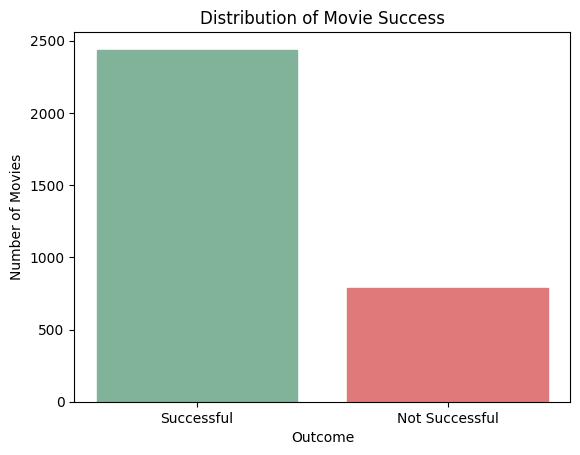

In [10]:
import matplotlib.pyplot as plt

print(df['success'].value_counts())
print(df['success'].mean())

# Map 0/1 to labels
labels = df['success'].map({0: 'Not Successful', 1: 'Successful'})
counts = labels.value_counts()

plt.figure()
bars = plt.bar(counts.index, counts.values)

bars[0].set_color('#81b29a')
bars[1].set_color('#e07a7a')

plt.title("Distribution of Movie Success")
plt.xlabel("Outcome")
plt.ylabel("Number of Movies")

plt.show()


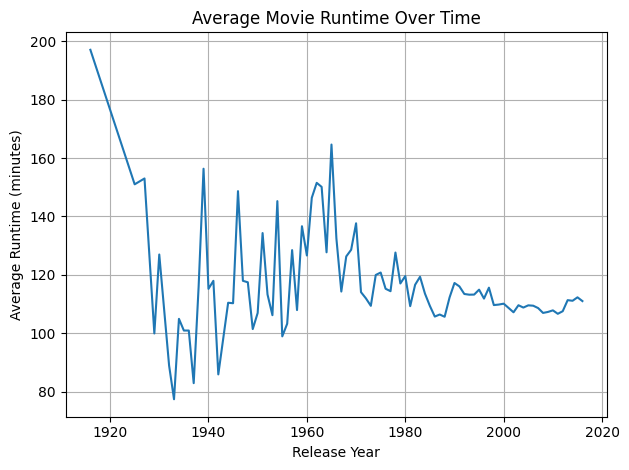

In [11]:
avg_runtime = df.groupby('release_year')['runtime'].mean()

plt.figure()
avg_runtime.plot()
plt.title("Average Movie Runtime Over Time")
plt.xlabel("Release Year")
plt.ylabel("Average Runtime (minutes)")
plt.grid(True)
plt.tight_layout()
plt.show()

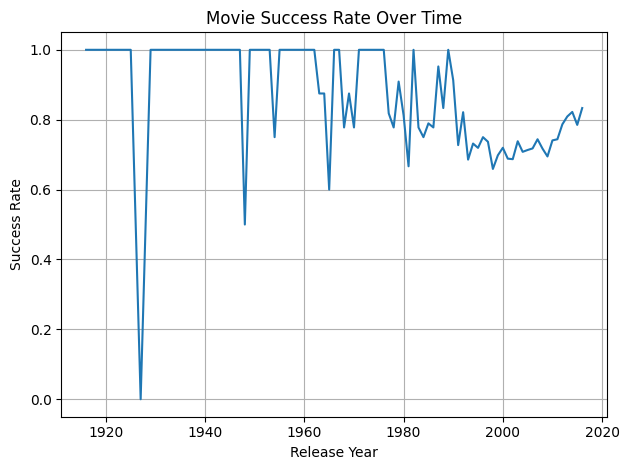

In [12]:
success_rate = df.groupby('release_year')['success'].mean()

plt.figure()
success_rate.plot()
plt.title("Movie Success Rate Over Time")
plt.xlabel("Release Year")
plt.ylabel("Success Rate")
plt.grid(True)
plt.tight_layout()
plt.show()


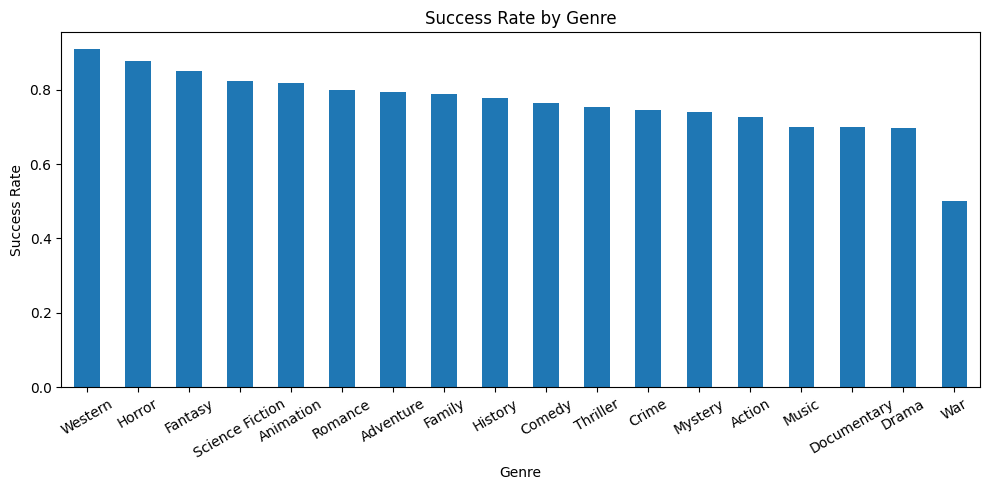

In [13]:
genre_success = df.groupby('genre')['success'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
genre_success.plot(kind='bar')
plt.title("Success Rate by Genre")
plt.xlabel("Genre")
plt.ylabel("Success Rate")
# Rotate the genre label
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 6.1. Checkpoint 1: Exploratory Data Analysis (15 points)

Submit a 2-page summary (not including figures) of your research question and exploratory data analysis. Teams of two should submit 3–4 pages. All writing must interpret graphs, statistics, and code for the reader in plain English; insufficient. Teams that wish to do sports analytics must check in with Tim to get clearance.

| Area                   | Criteria                                                                 | Points |
|------------------------|--------------------------------------------------------------------------|--------|
| Background & Objective | State the question, why it is interesting, and who benefits from the answer. | 3      |
| Dataset Summary        | Source, unit of analysis, number of observations, time period, and why this data can answer the question. | 3      |
| Data Preprocessing     | Cleaning steps: exclusions, combining sources, handling missing data. Justify each decision. Identify any feature transformations or engineering needed before modeling. | 3      |
| Outcome Variable       | Describe and visualize the response variable with appropriate summary statistics. | 3      |
| Key Predictors         | Select 2–3 key predictors guided by domain knowledge or EDA. Visualize their relationship to the outcome and interpret. | 3      |
| **Total**              |                                                                          | **15** |

You should investigate all predictors in your data as part of your project. For this checkpoint, pick two to three that you believe are most important and explain your reasoning.

https://docs.google.com/document/d/1zkQhnhllBYkGy7eG3SIB8X8lm0JOjyIHf2_b_LzpC1E/edit?usp=sharing

The goal of this project will be to identify and confirm which characteristics make a movie financially successful. Specifically, this report will analyze a TMDB movie dataset and features inside of it for each movie of genre, release year, and runtime. This problem is relevant to movie fans as well as studios and producers. Many fans enjoy predicting the success of a movie prior to its release and this will help them do so. Studios and producers will benefit from this as they rely on the financial return of the movies that they work on.

The dataset that will be used comes from Kaggle, and represents the data for around 5000 movies. For each of these movies, there is data for revenue, budget, release year, genre, and runtime, making this dataset appropriate to use for the question of “what features make a movie successful”. The substantial amounts of data about movies will be used to predict, and the revenue combined with the budget can be used to determine the success or failure of a movie. The dataset ranges from 1916 to 2016 which again contributes to the data being viable for the question.

Several steps were taken to format and clean the data prior to analyzing any movies. First, columns such as titles, descriptions, and production details were removed, as they do not contribute directly to predicting financial success. Then, data was reformatted to allow for easier reading. Release date was used to build a release year column, and a success column was created which equals 1 representing true if the budget was less than the revenue or 0 in the alternative. This allows the data to be used in a binary classification task which requires a (1,0) value. 
Any columns that contained null values or could not have the release date or success extrapolated were removed from the table. This brought the rows down to ~3000 which is still a high enough sample size to produce valid results.

The outcome variable in this analysis is the success feature mentioned above. A movie will be considered successful if its revenue is greater than its budget. The distribution of movies in this dataset is skewed more towards successful, but there is still a meaningful number of unsuccessful movies. Figure 1 shows this, with the successful movies in green and not successful in red.

				Figure 1 (Movie Success Distribution)
The key predictors for this analysis will be release year, genre, and runtime. These predictors were chosen due to their relation to the final product. Release year will influence the trends in the film industry, changing what types of movies are successful. Including this will capture those trends and ensure that the analysis is accurate for modern movies. Genre is the most important as it influences audience interest and demand. Certain genres in certain years may be much more successful than others which can be seen in Figure 2, where many of the genres are close in success but not at the same rate. The “War” genre can also be seen to have a much lower rate of success than every other genre.  
					Figure 2 (Success Rate By Genre)
Runtime represents how long the movie is, and the effective runtime of a movie may also be influenced by the release year. From Figure 3, it can be seen that movie runtime was more sporadic in the past but now it has leveled out and most modern movies are between 100 and 120 minutes.

			Figure 3 (Movie Runtime 1920-2020)
These predictors were chosen because they are relevant to the movie industry and have observable relationships with the outcome variable of success.


					







Works Cited
TMDB 5000 Movie Dataset. (n.d.). www.kaggle.com. https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata?resource=download
‌

## 6.2. Checkpoint 2: Baseline Model (15 points)

Submit a 2-page report (teams of two: 3–4 pages) describing your baseline model. This checkpoint focuses on a single, well-justified model with documented hyperparameter tuning.

| Area               | Criteria                                                                 | Points |
|--------------------|--------------------------------------------------------------------------|--------|
| Method Selection   | Identify the baseline model and provide concrete rationale for why it was chosen over alternatives (not just that it "can" be used). | 3      |
| Feature Engineering| Describe any feature transformations, encodings, or new features created for this model. Justify why these choices are appropriate. | 3      |
| Implementation     | Describe the training/evaluation paradigm: train-test split, cross-validation, and hyperparameter search strategy. | 3      |
| Results            | Report quantitative metrics with visualizations. Show evidence that the model is neither underfit nor overfit. | 4      |
| Discussion         | Interpret what the results mean for your research question. Discuss limitations and what you would change. | 2      |
| **Total**          |                                                                          | **15** |

Choosing a model 
I am doing a binary classification problem: Successful or not Successful

Logistic Regression
Pros:
    - Pretty easy, I remember the labs being very simple
    - Would be good to run and then go to something more complicated if it has issues?
Cons:
    - Assumes success has a linear relationship with the features
Ridge Classifier
Lasso
Decision Tree
Random Forest
SVM SVC
KNN


In [14]:
X = df[['budget', 'popularity', 'runtime', 'vote_average', 'release_year']]
y = df['success']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.7936016511867905
Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.34      0.43       220
           1       0.83      0.93      0.87       749

    accuracy                           0.79       969
   macro avg       0.70      0.63      0.65       969
weighted avg       0.77      0.79      0.77       969

Confusion Matrix:
 [[ 75 145]
 [ 55 694]]
